# 05 — Model Explainability & Final Insights (Google Colab Version)

**Project:** Hydraulic Condition Monitoring Dashboard  
**Stage:** Explainability / Interpretation / Final Analytical Insights  
**Execution Environment:** Google Colab

---

## 🎯 Purpose

This notebook explains the trained models produced in `04_modeling.ipynb`.

It is the interpretation layer of the project pipeline:

- `01_load_data.ipynb` → creates canonical dataset artifacts  
- `02_eda.ipynb` → explores the canonical dataset and saves EDA outputs  
- `03_feature_engineering.ipynb` → builds the final engineered feature matrix  
- `04_modeling.ipynb` → trains one classification model per target  
- `05_model_explain.ipynb` → explains what the models learned

---

## ✅ Main goals

This notebook should help answer:

1. Which engineered features matter most?
2. Are the same features important across targets, or does each subsystem behave differently?
3. Can we support the final dashboard and documentation with explainability visuals?
4. What are the main analytical takeaways a reviewer should remember?

---

## 💡 Why this Colab version exists

This project uses a mixed execution workflow because the downstream ML stages are memory-intensive.

The heavy notebooks are intended to run in **Google Colab** when local hardware is insufficient:

- `03_feature_engineering.ipynb`
- `04_modeling.ipynb`
- `05_model_explain.ipynb`

This notebook is therefore designed to be:
- more memory-safe,
- pipeline-aware,
- compatible with models saved from Colab workflows,
- better suited for larger engineered feature matrices.

---

## 📦 Expected inputs

This notebook expects the stabilized outputs from the previous steps:

- `data/processed/X_features_fe.parquet`
- `data/processed/y_labels.parquet`
- trained models under `models/`
- optional JSON / Markdown helper files under `artifacts/`

---

## 🧠 Explainability strategy

This notebook uses a layered approach:

- **Layer 1:** quick model inspection and feature-importance extraction  
- **Layer 2:** target-specific top-feature plots  
- **Layer 3:** SHAP analysis where supported and available  
- **Layer 4:** cross-target feature stability  
- **Layer 5:** final markdown-style business / technical interpretation

This makes the notebook robust even if one explainability method is unavailable in a given environment.

## 0. Colab setup

This notebook assumes your project is stored in Google Drive.

### Expected project location
A common pattern is:

`/content/drive/MyDrive/<your-project-folder>/`

Update the `PROJECT_DIR` variable in the next cell if your folder name is different.

In [1]:
# ============================================================
# 0. Colab setup and project paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ============================================================
# 0.1 Project paths, imports, and optional dependencies
# ============================================================

from pathlib import Path
import json
import warnings
import sys
import subprocess

# ---- Update this path if your project folder name differs ----
PROJECT_DIR = Path("/content/drive/MyDrive/hydraulic_dashboard")

if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f"Project folder not found at: {PROJECT_DIR}\n"
        "Please update PROJECT_DIR in this cell to match your Google Drive path."
    )

def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])

ensure_package("shap")
ensure_package("pyarrow")
ensure_package("joblib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.pipeline import Pipeline

SHAP_AVAILABLE = True

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

BASE_DIR = PROJECT_DIR
DATA_DIR = BASE_DIR / "data"
PROC_DIR = DATA_DIR / "processed"
META_DIR = DATA_DIR / "metadata"

MODELS_DIR = BASE_DIR / "models"
ARTIFACTS_DIR = BASE_DIR / "artifacts"

IMAGES_DIR = BASE_DIR / "images"
EXPLAIN_DIR = IMAGES_DIR / "model_explain"

EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR     :", BASE_DIR)
print("PROC_DIR     :", PROC_DIR)
print("META_DIR     :", META_DIR)
print("MODELS_DIR   :", MODELS_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("EXPLAIN_DIR  :", EXPLAIN_DIR)
print("SHAP_AVAILABLE:", SHAP_AVAILABLE)

BASE_DIR     : /content/drive/MyDrive/hydraulic_dashboard
PROC_DIR     : /content/drive/MyDrive/hydraulic_dashboard/data/processed
META_DIR     : /content/drive/MyDrive/hydraulic_dashboard/data/metadata
MODELS_DIR   : /content/drive/MyDrive/hydraulic_dashboard/models
ARTIFACTS_DIR: /content/drive/MyDrive/hydraulic_dashboard/artifacts
EXPLAIN_DIR  : /content/drive/MyDrive/hydraulic_dashboard/images/model_explain
SHAP_AVAILABLE: True


## 1. Load engineered features, targets, and helper artifacts

At this stage we only work with the final engineered features from Notebook 03 and the trained model files from Notebook 04.

This notebook does **not** re-train models.  
It is intentionally downstream-only.

In [3]:
# ============================================================
# 1. Load final feature matrix and labels
# ============================================================

X_path = PROC_DIR / "X_features_fe.parquet"
y_path = PROC_DIR / "y_labels.parquet"

if not X_path.exists():
    raise FileNotFoundError(f"Expected engineered features at: {X_path}")

if not y_path.exists():
    raise FileNotFoundError(f"Expected labels at: {y_path}")

X = pd.read_parquet(X_path)
y = pd.read_parquet(y_path)

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (2205, 130962)
y shape: (2205, 5)


,CE_t1,CE_t2,CE_t3,CE_t4,CE_t5,CE_t6,CE_t7,CE_t8,CE_t9,CE_t10,...,flow_group_min,pressure_group_min,temperature_group_min,vibration_group_min,cooler_group_max,electrical_group_max,flow_group_max,pressure_group_max,temperature_group_max,vibration_group_max
0,47.202,47.273,47.250,47.332,47.213,47.372,47.273,47.438,46.691,46.599,...,0.0,0.0,30.363,0.532,47.438,2951.6,18.710,191.51,41.250,0.624
1,29.208,28.822,28.805,28.922,28.591,28.643,28.216,27.812,27.514,27.481,...,0.0,0.0,33.648,0.524,29.208,2947.4,18.712,191.47,42.105,0.626
2,23.554,23.521,23.527,23.008,23.042,23.052,22.658,22.952,22.908,22.359,...,0.0,0.0,35.098,0.529,23.554,2939.8,18.698,191.41,43.039,0.662
3,21.540,21.419,21.565,20.857,21.052,21.039,20.926,20.912,20.989,20.882,...,0.0,0.0,36.105,0.527,21.565,2929.6,18.896,191.34,43.988,0.645
4,20.460,20.298,20.350,19.867,19.997,19.972,19.924,19.813,19.691,19.634,...,0.0,0.0,36.992,0.524,20.460,2923.8,18.876,191.41,44.887,0.660


,cooler_condition,valve_condition,internal_pump_leakage,hydraulic_accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


In [4]:
# ============================================================
# 1.1 Optional metadata / helper artifacts
# ============================================================

feature_index_json_path = ARTIFACTS_DIR / "feature_index.json"
training_summary_path = ARTIFACTS_DIR / "04_training_summary.md"

feature_index_artifact = None
training_summary_text = None

if feature_index_json_path.exists():
    with open(feature_index_json_path, "r", encoding="utf-8") as f:
        feature_index_artifact = json.load(f)
    print(f"Loaded feature index artifact: {feature_index_json_path.name}")
else:
    print("No feature_index.json found in artifacts/ (this is optional).")

if training_summary_path.exists():
    training_summary_text = training_summary_path.read_text(encoding="utf-8")
    print(f"Loaded training summary artifact: {training_summary_path.name}")
else:
    print("No 04_training_summary.md found in artifacts/ (this is optional).")

Loaded feature index artifact: feature_index.json
Loaded training summary artifact: 04_training_summary.md


## 1.2 Load model performance metrics

Explainability is stronger when it is viewed together with model performance.

This section loads a lightweight summary of per-target model metrics from Notebook 04 so that interpretation can be read together with predictive quality.

This helps answer:

- Which targets are both interpretable and strong-performing?
- Which targets may need more caution when interpreting feature importance?

In [5]:
# ============================================================
# 1.2 Load model performance metrics from Notebook 04
# ============================================================

metrics_path_artifacts = ARTIFACTS_DIR / "04_model_metrics.csv"
metrics_path_metadata = META_DIR / "04_model_metrics.csv"

metrics_df = None

if metrics_path_artifacts.exists():
    metrics_df = pd.read_csv(metrics_path_artifacts)
    print(f"Loaded model metrics from: {metrics_path_artifacts}")
elif metrics_path_metadata.exists():
    metrics_df = pd.read_csv(metrics_path_metadata)
    print(f"Loaded model metrics from: {metrics_path_metadata}")
else:
    print("No saved model metrics file found. This section is optional.")

if metrics_df is not None:
    display(metrics_df)

No saved model metrics file found. This section is optional.


## 2. Quick structural validation

Before interpreting anything, we verify that the explainability inputs are structurally sound.

We check:

- feature uniqueness
- missing values
- target columns
- model file availability

In [6]:
# ============================================================
# 2. Structural validation
# ============================================================

print("Unique feature columns:", X.columns.nunique(), "of", len(X.columns))
print("Duplicate feature columns:", X.columns.duplicated().sum())
print("Total missing values in X:", int(X.isna().sum().sum()))
print("Target columns:", list(y.columns))

assert X.columns.nunique() == len(X.columns), "Duplicate feature columns detected."
assert X.index.equals(y.index), "Feature and label indices are not aligned."

model_files = sorted(MODELS_DIR.glob("*_model.joblib"))
print("\nDetected model files:")
for p in model_files:
    print(" -", p.name)

if not model_files:
    raise FileNotFoundError(
        f"No trained model files found in {MODELS_DIR}. "
        "Please run 04_modeling.ipynb first."
    )

Unique feature columns: 130962 of 130962
Duplicate feature columns: 0
Total missing values in X: 0
Target columns: ['cooler_condition', 'valve_condition', 'internal_pump_leakage', 'hydraulic_accumulator', 'stable_flag']

Detected model files:
 - accumulator_model.joblib
 - cooler_model.joblib
 - pump_model.joblib
 - stable_model.joblib
 - valve_model.joblib


## 3. Helper functions

This section keeps the notebook clean and reusable.

The helpers below are designed to:
- load pipeline-based model artifacts safely,
- work across multiple model types,
- support both importance extraction and SHAP analysis,
- remain robust when older sklearn artifacts are loaded.

In [7]:
# ============================================================
# 3. Helper functions
# ============================================================

def pretty_title_from_model_name(model_path: Path) -> str:
    """Convert a file name like 'cooler_model.joblib' into a cleaner display title."""
    return model_path.stem.replace("_model", "").replace("_", " ").title()


def load_model(model_path: Path):
    """Load a model artifact using joblib with a compatibility fallback."""
    try:
        return joblib.load(model_path)

    except AttributeError as e:
        err_msg = str(e)

        if "_RemainderColsList" in err_msg:
            try:
                import sklearn.compose._column_transformer as ct_mod

                if not hasattr(ct_mod, "_RemainderColsList"):
                    class _RemainderColsList(list):
                        pass

                    ct_mod._RemainderColsList = _RemainderColsList

                print(
                    f"[Compatibility patch] Retrying model load for "
                    f"{model_path.name} after injecting _RemainderColsList."
                )
                return joblib.load(model_path)

            except Exception as inner_e:
                raise RuntimeError(
                    f"Failed to load model '{model_path.name}' even after "
                    f"compatibility patch."
                ) from inner_e

        raise RuntimeError(
            f"Failed to load model '{model_path.name}'. "
            f"This is likely due to a library version mismatch."
        ) from e


def infer_target_name_from_model_file(model_path: Path) -> str:
    """Infer the target column name from the saved model filename where possible."""
    base = model_path.stem.replace("_model", "")
    normalized = base.lower()

    for col in y.columns:
        if normalized in col.lower():
            return col

    return base


def unpack_pipeline_model(model):
    """Return (preprocess_step, final_estimator)."""
    if isinstance(model, Pipeline):
        if len(model.steps) < 2:
            return None, model
        preprocess = model.steps[0][1]
        final_estimator = model.steps[-1][1]
        return preprocess, final_estimator

    return None, model


def get_transformed_feature_names(preprocess, X_raw: pd.DataFrame):
    """Try to recover transformed feature names after preprocessing."""
    try:
        names = preprocess.get_feature_names_out(X_raw.columns)
        return list(names)
    except Exception:
        try:
            transformed = preprocess.transform(X_raw)
            return [f"feature_{i}" for i in range(transformed.shape[1])]
        except Exception:
            return list(X_raw.columns)


def get_feature_importance(model, X_raw: pd.DataFrame):
    """Extract feature importance from either a bare estimator or a Pipeline."""
    preprocess, estimator = unpack_pipeline_model(model)

    if preprocess is not None:
        try:
            preprocess.transform(X_raw)
            feature_names = get_transformed_feature_names(preprocess, X_raw)
        except Exception as e:
            print(f"Could not transform features for importance extraction: {e}")
            return None
    else:
        feature_names = list(X_raw.columns)

    if hasattr(estimator, "feature_importances_"):
        values = getattr(estimator, "feature_importances_")
        if values is not None and len(values) == len(feature_names):
            return pd.Series(values, index=feature_names).sort_values(ascending=False)

    if hasattr(estimator, "coef_"):
        coef = np.asarray(getattr(estimator, "coef_"))

        if coef.ndim == 1 and len(coef) == len(feature_names):
            return pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False)

        if coef.ndim == 2 and coef.shape[1] == len(feature_names):
            return pd.Series(np.abs(coef).mean(axis=0), index=feature_names).sort_values(ascending=False)

    try:
        booster = estimator.get_booster()
        gain_scores = booster.get_score(importance_type="gain")

        if gain_scores:
            mapped = {}
            for k, v in gain_scores.items():
                if k.startswith("f") and k[1:].isdigit():
                    idx = int(k[1:])
                    if idx < len(feature_names):
                        mapped[feature_names[idx]] = v
                else:
                    mapped[k] = v

            out = pd.Series(mapped).reindex(feature_names).fillna(0.0)
            return out.sort_values(ascending=False)

    except Exception:
        pass

    return None


def save_barplot(series: pd.Series, title: str, save_path: Path, top_n: int = 20):
    """Save a horizontal bar chart for the top-n most important features."""
    plot_data = series.head(top_n).sort_values(ascending=True)

    plt.figure(figsize=(10, max(6, top_n * 0.28)))
    plot_data.plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def try_shap_summary(model, X_raw: pd.DataFrame, title: str, save_path: Path):
    """Attempt SHAP summary plot generation in a pipeline-aware way."""
    if not SHAP_AVAILABLE:
        print(f"SHAP skipped for '{title}' because shap is not installed.")
        return False

    preprocess, estimator = unpack_pipeline_model(model)

    try:
        if preprocess is not None:
            X_transformed = preprocess.transform(X_raw)
            feature_names = get_transformed_feature_names(preprocess, X_raw)
            X_for_shap = pd.DataFrame(X_transformed, columns=feature_names)
        else:
            X_for_shap = X_raw.copy()

        try:
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(X_for_shap)

            plt.figure(figsize=(10, 6))
            shap.summary_plot(shap_values, X_for_shap, max_display=20, show=False)
            plt.title(title)
            plt.tight_layout()
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.show()
            return True

        except Exception:
            explainer = shap.Explainer(estimator, X_for_shap)
            shap_values = explainer(X_for_shap)

            plt.figure()
            shap.plots.beeswarm(shap_values, max_display=20, show=False)
            plt.title(title)
            plt.tight_layout()
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.show()
            return True

    except Exception as e:
        print(f"SHAP could not be generated for '{title}': {e}")
        return False

## 4. Global overview of engineered features

Before going target by target, it is useful to understand the global feature space.

This section gives a lightweight summary of:

- number of features
- numeric distribution
- top variance features
- optional grouping hints from metadata

This Colab version uses a more memory-safe variance computation.

In [8]:
# ============================================================
# 4. Global feature-space overview (memory-safer version)
# ============================================================

print("Total engineered features:", X.shape[1])

summary_df = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing_count": X.isna().sum(),
    "n_unique": X.nunique(dropna=False)
})

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    X_num = X[numeric_cols].astype("float32")

    variance_values = {}
    for col in X_num.columns:
        variance_values[col] = X_num[col].var()

    variance_series = pd.Series(variance_values).sort_values(ascending=False)

    print("\nTop 15 features by variance:")
    display(variance_series.head(15).to_frame("variance"))
else:
    variance_series = pd.Series(dtype=float)
    print("No numeric columns found.")

display(summary_df.head(20))

Total engineered features: 130962

Top 15 features by variance:


,variance
EPS1_t993,23158.330078
EPS1_t994,23154.996094
EPS1_t992,23067.402344
EPS1_t995,23039.986328
EPS1_t996,23000.613281
EPS1_t991,22868.449219
EPS1_t997,22818.443359
EPS1_t998,22681.714844
EPS1_t990,22546.529297
EPS1_t999,22354.269531


,dtype,missing_count,n_unique
CE_t1,float64,0,1732
CE_t2,float64,0,1752
CE_t3,float64,0,1735
CE_t4,float64,0,1754
CE_t5,float64,0,1759
CE_t6,float64,0,1749
CE_t7,float64,0,1729
CE_t8,float64,0,1761
CE_t9,float64,0,1765
CE_t10,float64,0,1734


In [9]:
# ============================================================
# 4.1 Optional feature grouping view from metadata / artifacts
# ============================================================

if feature_index_artifact is not None:
    print("Feature index artifact preview:")
    if isinstance(feature_index_artifact, dict):
        preview_items = list(feature_index_artifact.items())[:10]
        display(pd.DataFrame(preview_items, columns=["key", "value"]))
    elif isinstance(feature_index_artifact, list):
        display(pd.DataFrame(feature_index_artifact).head(10))
    else:
        print(type(feature_index_artifact), "artifact loaded but not tabular.")
else:
    print("Feature index artifact not available; skipping grouping preview.")

Feature index artifact preview:


,key,value
0,feature_order,"[CE_t1, CE_t2, CE_t3, CE_t4, CE_t5, CE_t6, CE_..."


## 5. Target-by-target model interpretation

This is the core explainability loop.

For each trained model, we:

1. load the model
2. estimate feature importance
3. save a top-feature chart
4. attempt SHAP analysis when possible
5. write down a quick interpretation note

This keeps the notebook practical and directly reusable for later dashboard or presentation work.


MODEL: accumulator_model.joblib
Display title: Accumulator
Inferred target: hydraulic_accumulator


,importance
feature_346,0.058808
feature_461,0.046507
feature_126,0.040484
feature_347,0.020957
feature_41,0.013763
feature_488,0.013049
feature_255,0.012865
feature_127,0.012561
feature_124,0.011414
feature_380,0.010991


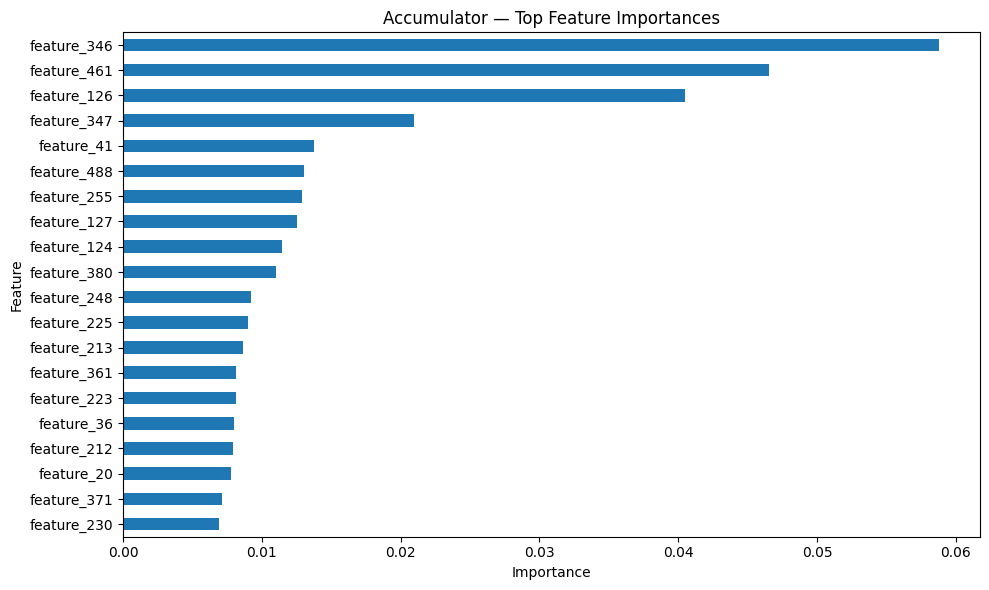

<Figure size 1000x600 with 0 Axes>

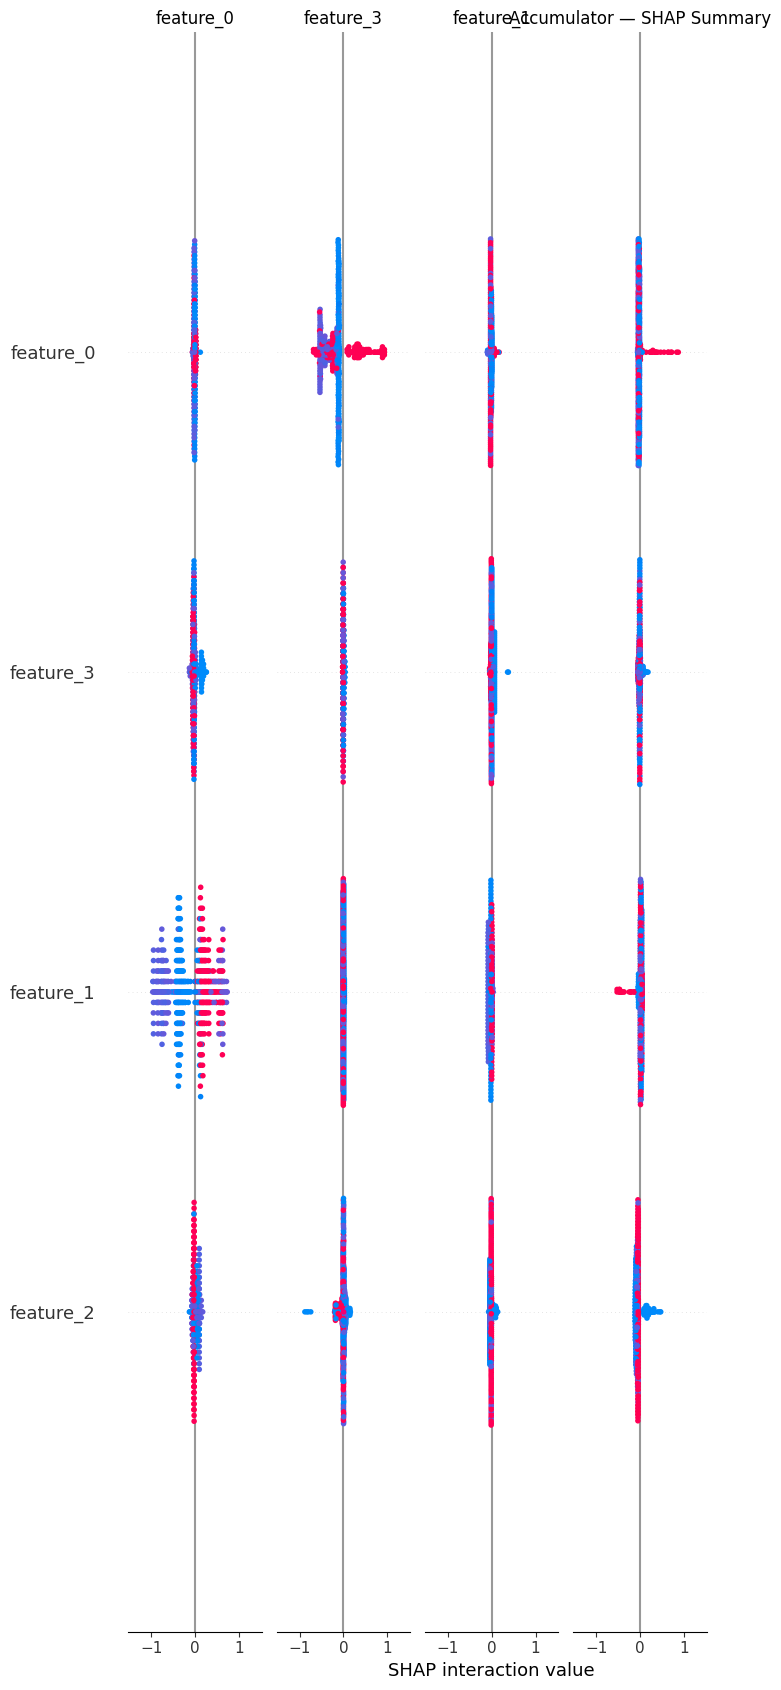


MODEL: cooler_model.joblib
Display title: Cooler
Inferred target: cooler_condition


,importance
feature_54,0.283500
feature_97,0.081238
feature_95,0.070626
feature_126,0.059273
feature_104,0.056483
feature_108,0.055136
feature_100,0.052638
feature_34,0.047536
feature_106,0.036508
feature_102,0.033167


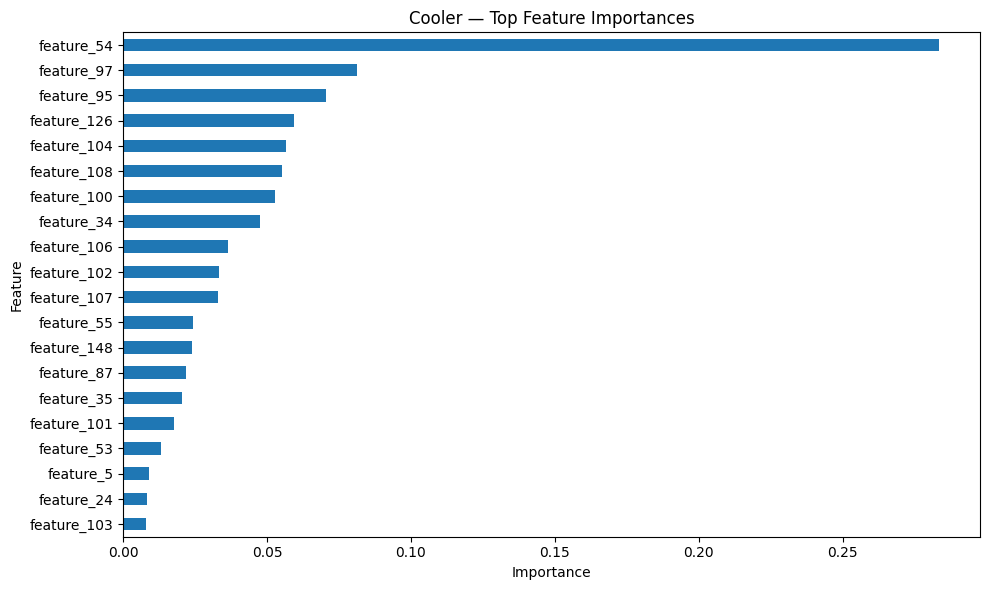

<Figure size 1000x600 with 0 Axes>

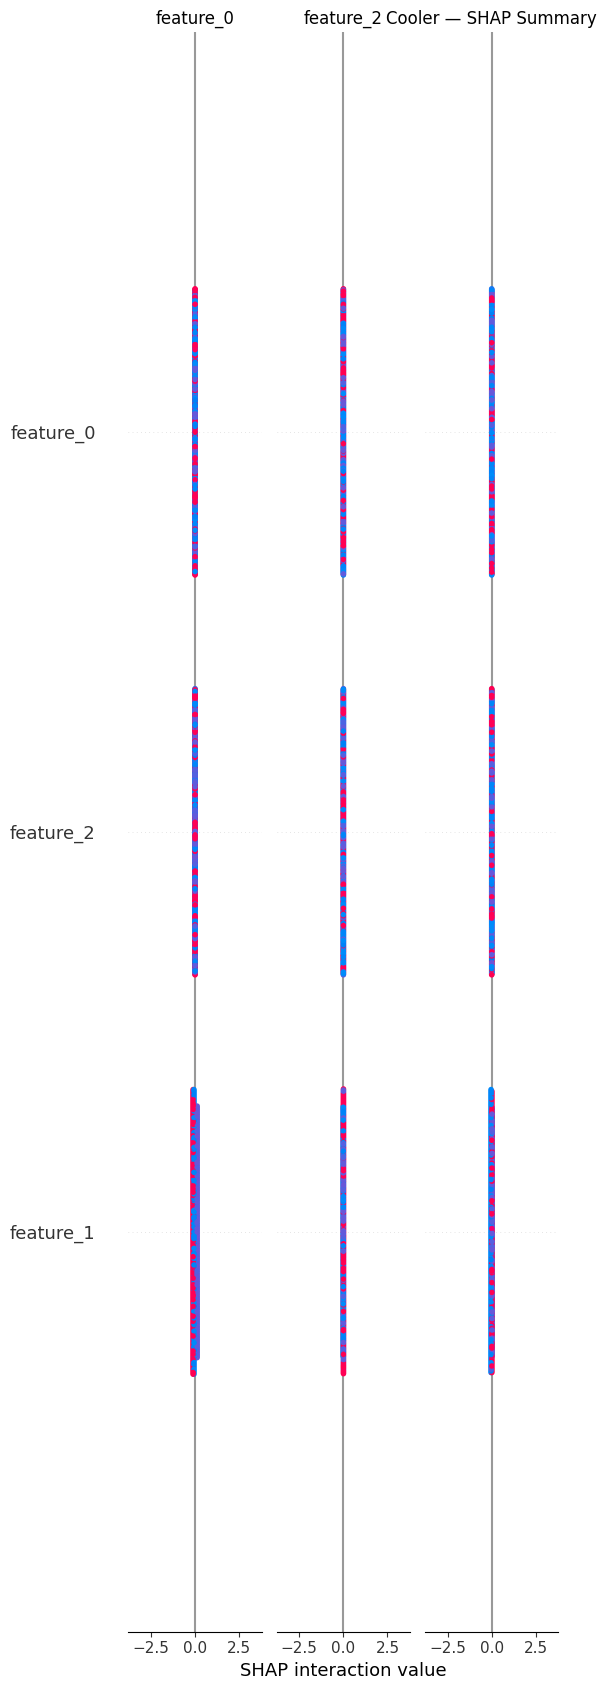


MODEL: pump_model.joblib
Display title: Pump
Inferred target: internal_pump_leakage


,importance
feature_340,0.033161
feature_450,0.029435
feature_321,0.026876
feature_99,0.024452
feature_253,0.021189
feature_400,0.019070
feature_350,0.018899
feature_354,0.016215
feature_386,0.015923
feature_336,0.013639


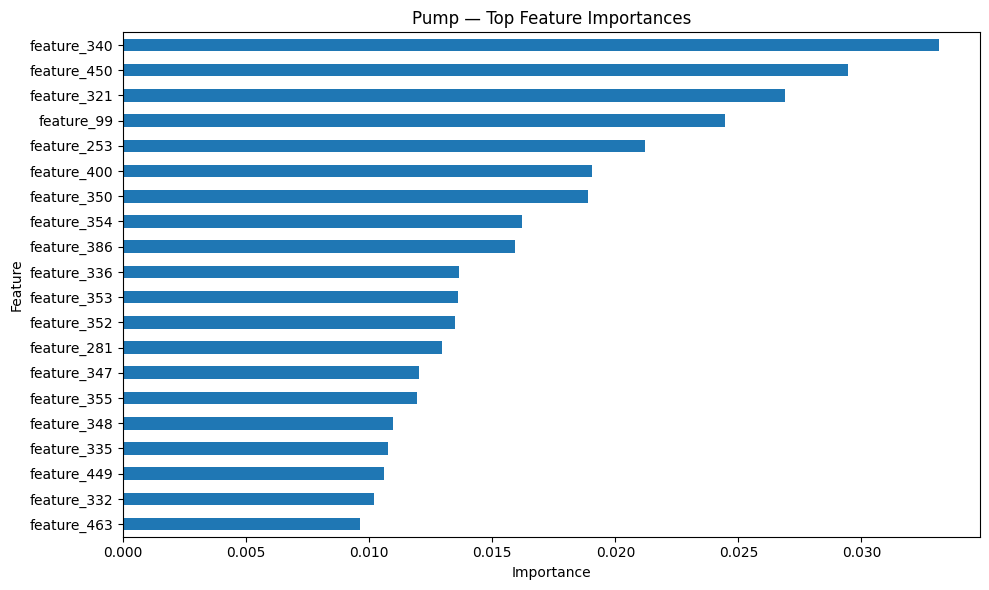

<Figure size 1000x600 with 0 Axes>

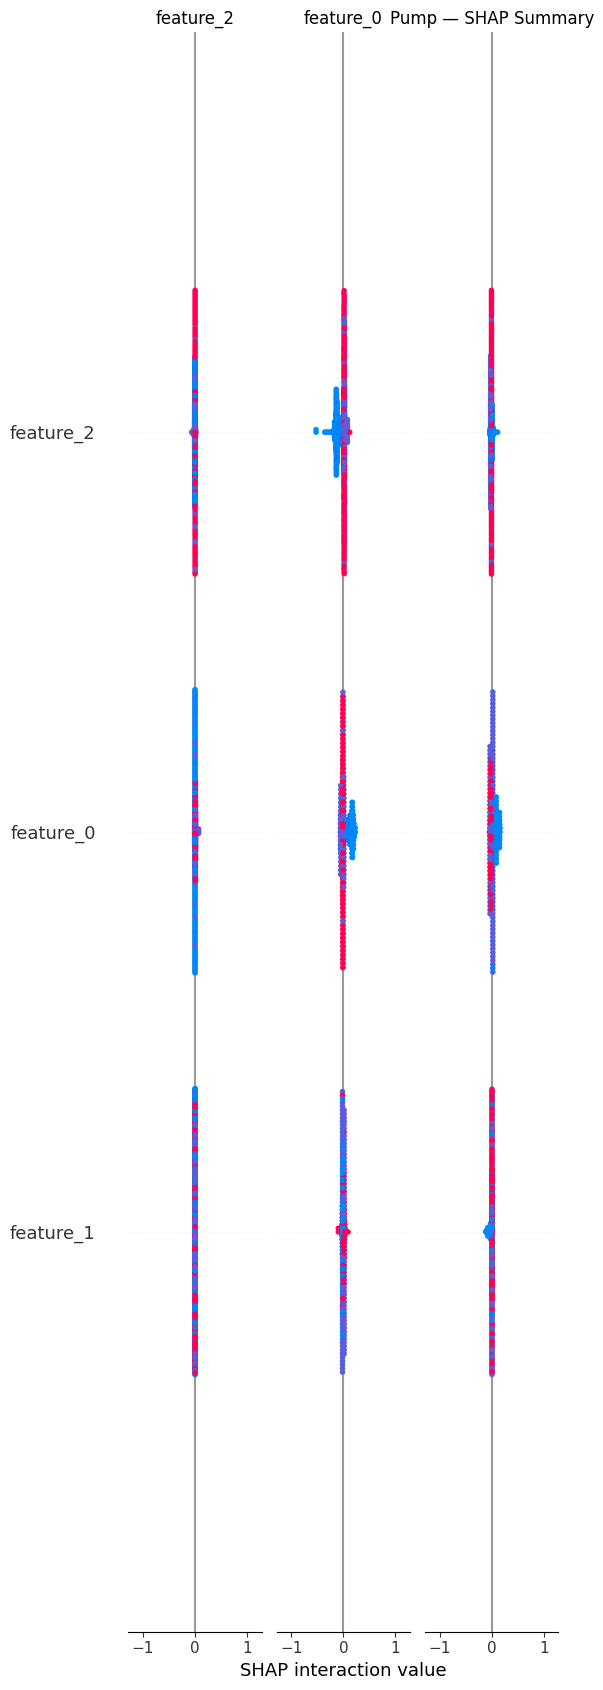


MODEL: stable_model.joblib
Display title: Stable
Inferred target: stable_flag


,importance
feature_426,0.029434
feature_416,0.026723
feature_377,0.026350
feature_388,0.025058
feature_130,0.020397
feature_352,0.016162
feature_226,0.015334
feature_40,0.014828
feature_439,0.014813
feature_126,0.014309


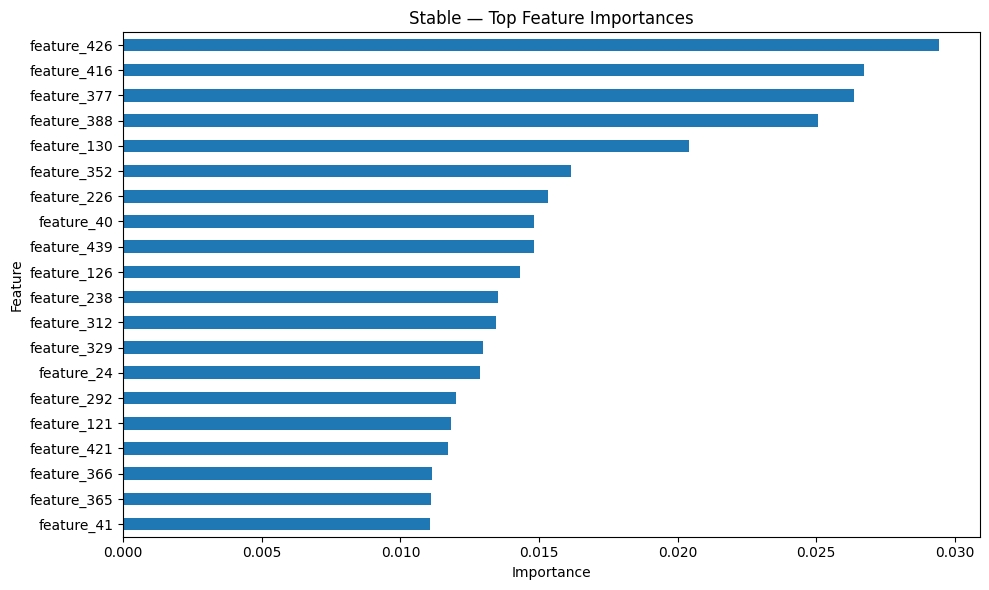

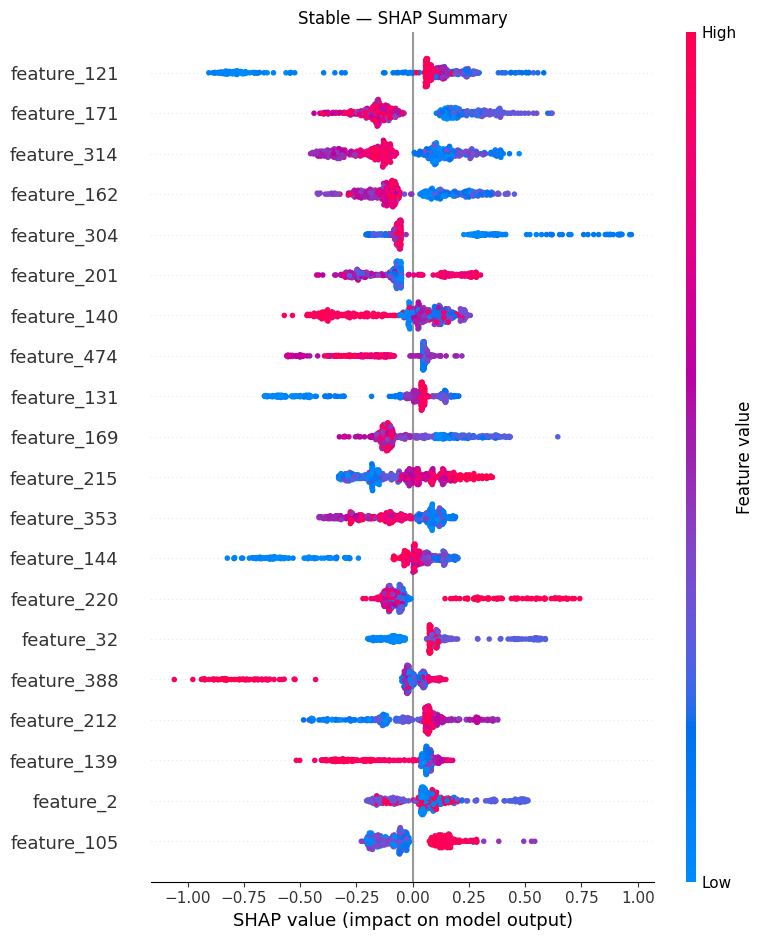


MODEL: valve_model.joblib
Display title: Valve
Inferred target: valve_condition


,importance
feature_274,0.013336
feature_135,0.011331
feature_416,0.009550
feature_131,0.008336
feature_437,0.007812
feature_364,0.007645
feature_362,0.007377
feature_310,0.007246
feature_133,0.006655
feature_354,0.006650


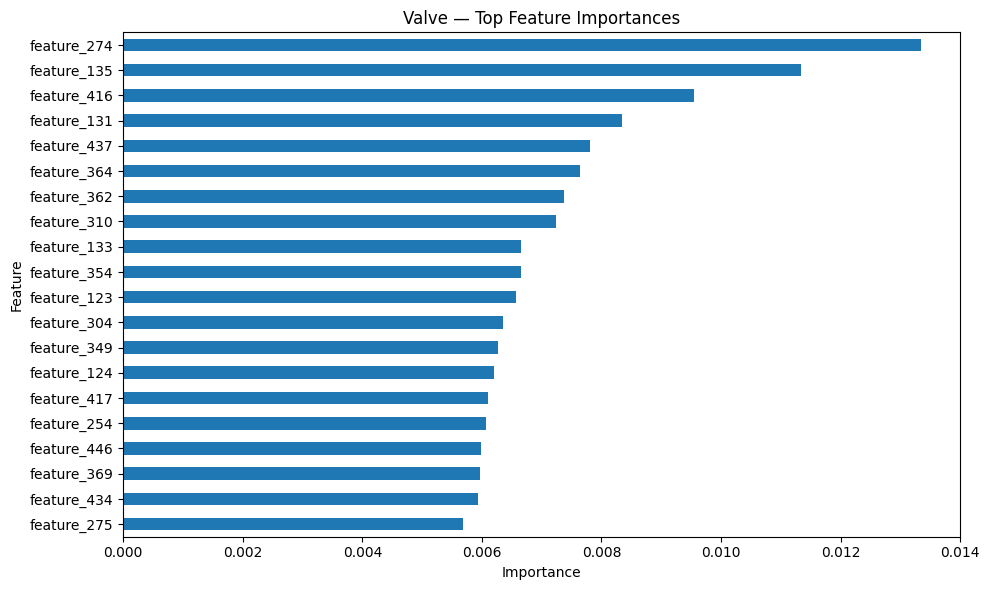

<Figure size 1000x600 with 0 Axes>

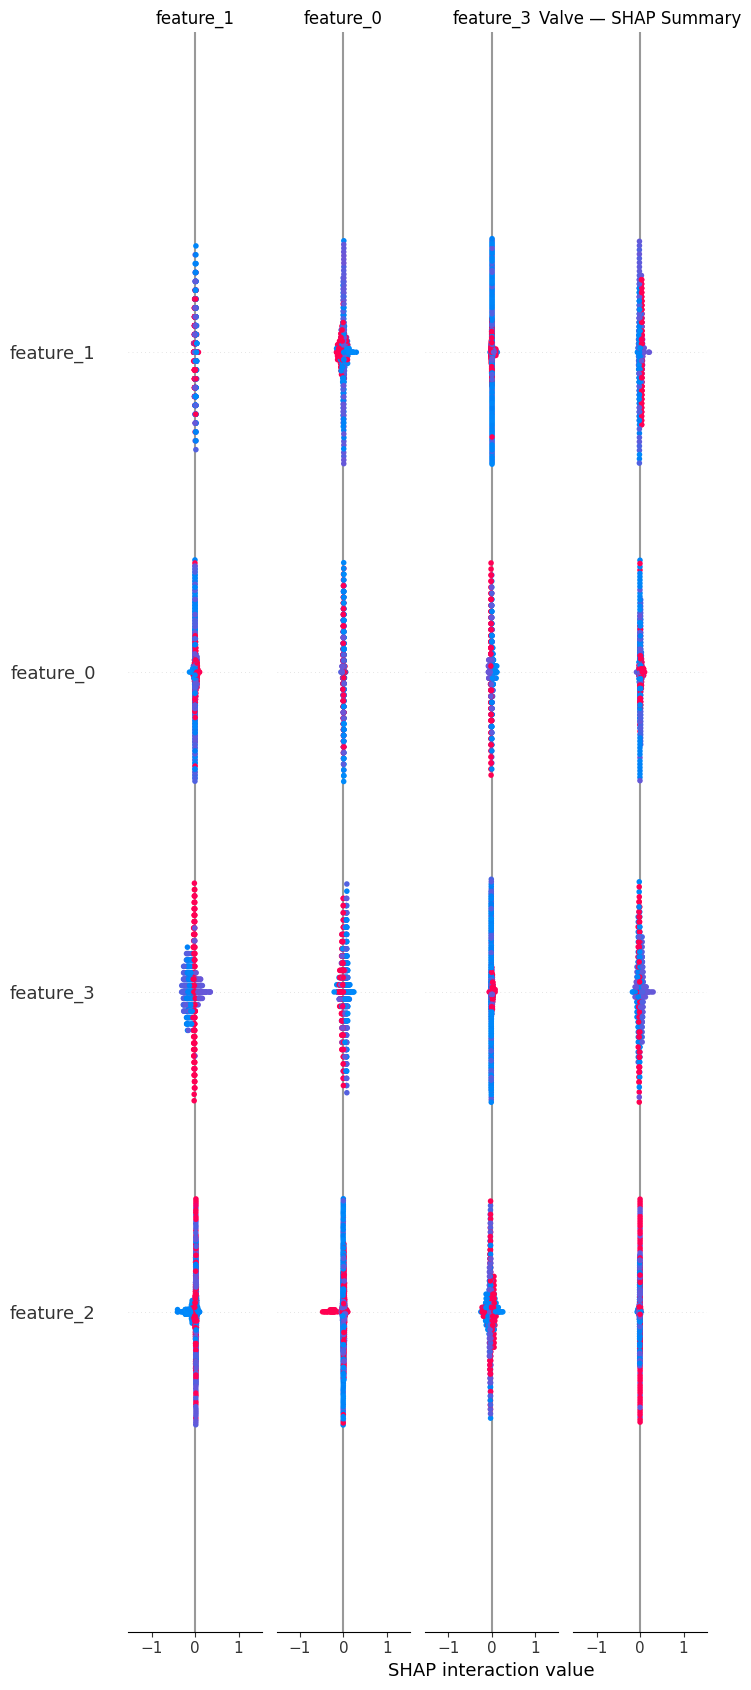


Interpretation loop finished.


In [10]:
# ============================================================
# 5. Model-by-model interpretation loop
# ============================================================

sample_size = min(500, len(X))
X_sample = X.sample(n=sample_size, random_state=42) if len(X) > sample_size else X.copy()

importance_tables = {}
interpretation_notes = []

for model_path in model_files:
    print("\n" + "=" * 80)
    print("MODEL:", model_path.name)
    print("=" * 80)

    model = load_model(model_path)
    model_title = pretty_title_from_model_name(model_path)
    target_name = infer_target_name_from_model_file(model_path)

    print("Display title:", model_title)
    print("Inferred target:", target_name)

    importance = get_feature_importance(model, X)

    if importance is not None:
        importance_tables[target_name] = importance

        display(importance.head(15).to_frame("importance"))

        importance_plot_path = EXPLAIN_DIR / f"{model_path.stem}_top_features.png"
        save_barplot(
            importance,
            title=f"{model_title} — Top Feature Importances",
            save_path=importance_plot_path,
            top_n=20
        )

        top_5 = importance.head(5).index.tolist()
        note = (
            f"Target '{target_name}': strongest signal appears to come from "
            f"{', '.join(top_5[:3])}"
            + (" and others." if len(top_5) > 3 else ".")
        )
    else:
        note = (
            f"Target '{target_name}': direct feature importance extraction "
            "was not available for the loaded model."
        )
        print(note)

    shap_plot_path = EXPLAIN_DIR / f"{model_path.stem}_shap_beeswarm.png"
    shap_ok = try_shap_summary(
        model=model,
        X_raw=X_sample,
        title=f"{model_title} — SHAP Summary",
        save_path=shap_plot_path
    )

    if shap_ok:
        note += " SHAP summary was successfully generated."
    else:
        note += " SHAP summary was skipped or unavailable in this environment."

    interpretation_notes.append({
        "target": target_name,
        "model_file": model_path.name,
        "note": note
    })

print("\nInterpretation loop finished.")

## 6. Consolidated importance table

This section creates a compact, reviewer-friendly comparison table across all targets.

It helps answer:

- Which features repeatedly appear among the most important?
- Which features are target-specific?

In [11]:
# ============================================================
# 6. Consolidated importance comparison
# ============================================================

if importance_tables:
    top_n = 10
    consolidated_rows = []

    for target_name, imp in importance_tables.items():
        tmp = imp.head(top_n).reset_index()
        tmp.columns = ["feature", "importance"]
        tmp["target"] = target_name
        tmp["rank"] = np.arange(1, len(tmp) + 1)
        consolidated_rows.append(tmp)

    consolidated_df = pd.concat(consolidated_rows, ignore_index=True)
    display(consolidated_df)

    consolidated_csv_path = ARTIFACTS_DIR / "top_features_across_targets.csv"
    consolidated_df.to_csv(consolidated_csv_path, index=False)
    print(f"Saved consolidated comparison to: {consolidated_csv_path}")
else:
    consolidated_df = pd.DataFrame()
    print("No importance tables available to consolidate.")

,feature,importance,target,rank
0,feature_346,0.058808,hydraulic_accumulator,1
1,feature_461,0.046507,hydraulic_accumulator,2
2,feature_126,0.040484,hydraulic_accumulator,3
3,feature_347,0.020957,hydraulic_accumulator,4
4,feature_41,0.013763,hydraulic_accumulator,5
5,feature_488,0.013049,hydraulic_accumulator,6
6,feature_255,0.012865,hydraulic_accumulator,7
7,feature_127,0.012561,hydraulic_accumulator,8
8,feature_124,0.011414,hydraulic_accumulator,9
9,feature_380,0.010991,hydraulic_accumulator,10


Saved consolidated comparison to: /content/drive/MyDrive/hydraulic_dashboard/artifacts/top_features_across_targets.csv


## 6.1 Cross-target feature stability

This section asks a higher-level question:

**Which engineered features repeatedly appear among the most important across multiple targets?**

If the same features or feature families recur across several subsystem models, that suggests they may capture broader hydraulic-system health patterns rather than only target-specific effects.

This is valuable for:
- portfolio storytelling,
- model interpretation,
- and future dashboard simplification.

Top recurring features across targets (top 15 per target):


,feature,frequency
0,feature_126,3
1,feature_347,2
2,feature_416,2
3,feature_124,2
4,feature_352,2
5,feature_354,2
6,feature_346,1
7,feature_461,1
8,feature_127,1
9,feature_41,1


Saved cross-target stability summary to: /content/drive/MyDrive/hydraulic_dashboard/artifacts/cross_target_feature_stability.csv


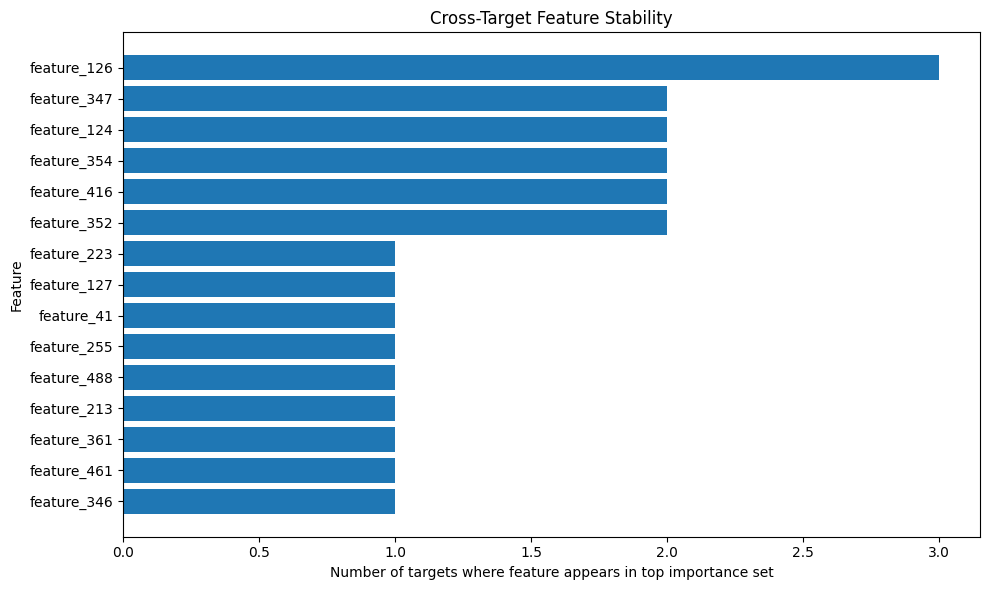

In [12]:
# ============================================================
# 6.1 Cross-target feature stability
# ============================================================

if importance_tables:
    top_k = 15

    recurring = pd.concat(
        [imp.head(top_k).index.to_series(name="feature") for imp in importance_tables.values()],
        axis=0
    ).value_counts().rename("frequency")

    recurring_df = recurring.reset_index()
    recurring_df.columns = ["feature", "frequency"]

    print(f"Top recurring features across targets (top {top_k} per target):")
    display(recurring_df.head(20))

    recurring_path = ARTIFACTS_DIR / "cross_target_feature_stability.csv"
    recurring_df.to_csv(recurring_path, index=False)
    print(f"Saved cross-target stability summary to: {recurring_path}")

    top_plot = recurring_df.head(15).sort_values("frequency", ascending=True)

    plt.figure(figsize=(10, max(6, len(top_plot) * 0.35)))
    plt.barh(top_plot["feature"], top_plot["frequency"])
    plt.title("Cross-Target Feature Stability")
    plt.xlabel("Number of targets where feature appears in top importance set")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(EXPLAIN_DIR / "cross_target_feature_stability.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    print("No importance tables available; skipping cross-target feature stability analysis.")

## 7. Final analytical takeaways

This section is intentionally written in plain language.

Use it to summarize the main explainability findings in a way that helps:

- technical reviewers,
- hiring managers,
- portfolio readers,
- future dashboard users.

You can revise these markdown bullets after reviewing the generated plots.

In [13]:
# ============================================================
# 7. Generate notebook-friendly takeaway text
# ============================================================

if importance_tables:
    recurring_features = pd.concat(
        [imp.head(10).index.to_series() for imp in importance_tables.values()],
        axis=0
    ).value_counts()

    print("Most recurring top-ranked features across targets:")
    display(recurring_features.head(15).to_frame("top10_frequency"))

display(pd.DataFrame(interpretation_notes))

if metrics_df is not None:
    print("\nModel metrics are available. Use them together with feature importance to interpret confidence and performance by target.")

Most recurring top-ranked features across targets:


,top10_frequency
feature_126,3
feature_354,2
feature_416,2
feature_347,1
feature_461,1
feature_346,1
feature_255,1
feature_127,1
feature_124,1
feature_380,1


,target,model_file,note
0,hydraulic_accumulator,accumulator_model.joblib,Target 'hydraulic_accumulator': strongest sign...
1,cooler_condition,cooler_model.joblib,Target 'cooler_condition': strongest signal ap...
2,internal_pump_leakage,pump_model.joblib,Target 'internal_pump_leakage': strongest sign...
3,stable_flag,stable_model.joblib,Target 'stable_flag': strongest signal appears...
4,valve_condition,valve_model.joblib,Target 'valve_condition': strongest signal app...


### Suggested interpretation template

Use the results above to complete and refine the project narrative.

#### Example structure for final takeaways

- **Subsystem-specific behavior:** Different targets may rely on different sensor-derived feature families, suggesting that each hydraulic subsystem expresses degradation differently.
- **Recurring feature families:** If the same engineered features appear repeatedly across targets, they are likely strong general indicators of abnormal operating state.
- **Engineering value of feature creation:** The importance rankings validate that Notebook 03 did more than add complexity — it created signal-rich features that the models actually use.
- **Performance-aware interpretation:** If model metrics differ by target, interpretation should be read together with predictive quality rather than in isolation.
- **Portfolio significance:** This notebook strengthens the project by showing not only predictive performance, but also model transparency and interpretable analytical reasoning.

#### What to update manually after running
After you review the actual top-feature plots and SHAP visuals, replace this generic template with:
- your real top recurring features,
- the most interesting target-specific patterns,
- one or two concise final insights for README / slides.

## 8. Optional export summary

This final section saves a lightweight Markdown summary file that can later support documentation or portfolio writing.

In [14]:
# ============================================================
# 8. Export lightweight explainability summary
# ============================================================

summary_lines = [
    "# 05_model_explain — Explainability Summary",
    "",
    f"- Total engineered features: **{X.shape[1]}**",
    f"- Number of targets analyzed: **{len(model_files)}**",
    f"- SHAP available in environment: **{SHAP_AVAILABLE}**",
    "",
    "## Model Notes",
]

for row in interpretation_notes:
    summary_lines.append(f"- **{row['target']}** (`{row['model_file']}`): {row['note']}")

if metrics_df is not None:
    summary_lines.extend([
        "",
        "## Performance Note",
        "Model metrics were loaded successfully and should be considered together with explainability outputs."
    ])

summary_md = "\n".join(summary_lines)
summary_path = ARTIFACTS_DIR / "05_explain_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")

print(f"Saved explainability summary to: {summary_path}")
print("\nPreview:\n")
print(summary_md[:1200])

Saved explainability summary to: /content/drive/MyDrive/hydraulic_dashboard/artifacts/05_explain_summary.md

Preview:

# 05_model_explain — Explainability Summary

- Total engineered features: **130962**
- Number of targets analyzed: **5**
- SHAP available in environment: **True**

## Model Notes
- **hydraulic_accumulator** (`accumulator_model.joblib`): Target 'hydraulic_accumulator': strongest signal appears to come from feature_346, feature_461, feature_126 and others. SHAP summary was successfully generated.
- **cooler_condition** (`cooler_model.joblib`): Target 'cooler_condition': strongest signal appears to come from feature_54, feature_97, feature_95 and others. SHAP summary was successfully generated.
- **internal_pump_leakage** (`pump_model.joblib`): Target 'internal_pump_leakage': strongest signal appears to come from feature_340, feature_450, feature_321 and others. SHAP summary was successfully generated.
- **stable_flag** (`stable_model.joblib`): Target 'stable_flag': stron

---

## ✅ End of Notebook 05

At this point, the project has a complete analytical flow:

1. **Load and standardize data**
2. **Explore data**
3. **Engineer features**
4. **Train models**
5. **Explain model behavior**

This is the exact kind of end-to-end structure that makes the project stronger for both technical reviewers and portfolio presentation.

### Final recommendation

For this project, the most reliable execution split is:

- `01_load_data.ipynb` → local or Colab
- `02_eda.ipynb` → local or Colab
- `03_feature_engineering.ipynb` → Colab recommended
- `04_modeling.ipynb` → Colab recommended
- `05_model_explain.ipynb` → Colab recommended